# 1 Duration

- 10 years to maturity

- coupon rate of 3%

- yield to maturity (semiannual) is 5%



## 1.1 

In [7]:

def duration(y, c, n, tau):
    y_adjusted = y / n
    c_adjusted = c / n
    tau_adjusted = tau * n
    duration = (1 / n) * ((1 + y_adjusted) / y_adjusted - (1 + y_adjusted + tau_adjusted * (c_adjusted - y_adjusted)) / (c_adjusted * ((1 + y_adjusted) ** tau_adjusted - 1) + y_adjusted))
    return duration


print(f"Duration of the bond: {duration(y=0.05, c=0.03, n=2, tau=10):.4f} years")

Duration of the bond: 8.5709 years


## 1.2 C =7%

In [8]:
print(f"Duration of the bond: {duration(y=0.05, c=0.07, n=2, tau=10):.4f} years")

Duration of the bond: 7.5648 years


## 1.3 C = 5%

In [9]:
print(f"Duration of the bond: {duration(y=0.05, c=0.05, n=2, tau=10):.4f} years")

Duration of the bond: 7.9894 years


## 1.4
- As the coupon rate increase, the duration decreases since more cash arrives sooner

# 2 Hedging Duration

## 2.1

In [15]:
import pandas as pd

filepath = "../Data/treasury_ts_duration_2025-05-30.xlsx"

SHEET_CLEAN = 'clean price'
SHEET_DIRTY = 'dirty price'
SHEET_DURATION = 'duration'
INDEX_NAME = 'quote date'

clean = pd.read_excel(filepath,sheet_name=SHEET_CLEAN).set_index(INDEX_NAME)
dirty = pd.read_excel(filepath,sheet_name=SHEET_DIRTY).set_index(INDEX_NAME)
duration = pd.read_excel(filepath,sheet_name=SHEET_DURATION).set_index(INDEX_NAME)
display(dirty.head())
display(duration.head())

,207391,207392
quote date,,
2019-08-09,98.882812,99.789062
2019-08-12,99.796875,102.554688
2019-08-13,99.281250,101.867188
2019-08-14,100.406250,105.179688
2019-08-15,100.882812,106.234375


,207391,207392
quote date,,
2019-08-09,9.289497,22.000102
2019-08-12,9.285468,22.118496
2019-08-13,9.280314,22.084308
2019-08-14,9.282750,22.228549
2019-08-15,9.282163,22.270910


In [63]:
interest_ratio = float(duration.loc['2023-11-09',:].loc[207391]) * float(dirty.loc['2023-11-09',:].loc[207391]) / (float(duration.loc['2023-11-09',:].loc[207392]) * float(dirty.loc['2023-11-09',:].loc[207392]))
print(f"interest_ratio: {interest_ratio}")
short_dollar = 10000 * interest_ratio
print(f"short_dollar: {short_dollar}")

interest_ratio: 0.4299422815428037
short_dollar: 4299.422815428036


## 2.2 

In [34]:
print(len(dirty))
print(len(duration))

1454
1454


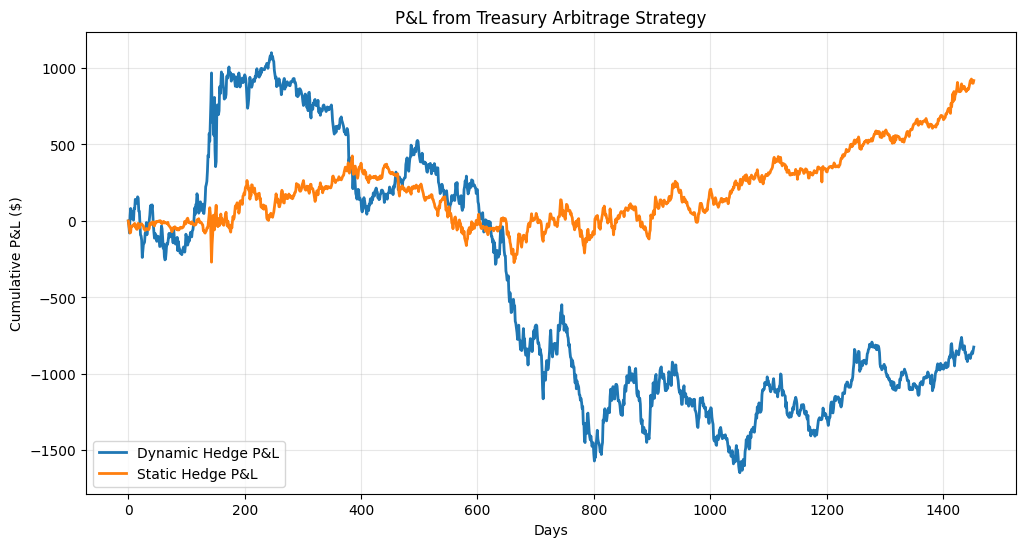

Final Dynamic Hedge P&L: $-824.51
Final Static Hedge P&L: $917.81


In [66]:
long_dollar = 10000
initial_date = dirty.index[0]  # or '2023-11-09' if that's your start date
initial_long_price = dirty.loc[initial_date, 207391]
initial_short_price = dirty.loc[initial_date, 207392]

# Fixed number of long bonds
long_position = long_dollar / initial_long_price

# Initial short positions (both start the same)
dynamic_short_position = short_dollar / initial_short_price
static_short_position = short_dollar / initial_short_price  # This stays fixed

dynamic_pnl = 0
static_pnl = 0
dynamic_pnl_list = [0]
static_pnl_list = [0]

for i in range(1, len(dirty)):
    prev_date = dirty.index[i-1]
    curr_date = dirty.index[i]

    # Calculate P&L using the positions held during the period
    long_pnl = long_position * (dirty.loc[curr_date, 207391] - dirty.loc[prev_date, 207391])
    
    # Dynamic Hedge P&L - uses dynamic_short_position
    dynamic_short_pnl = dynamic_short_position * (dirty.loc[curr_date, 207392] - dirty.loc[prev_date, 207392])
    dynamic_pnl += long_pnl - dynamic_short_pnl
    dynamic_pnl_list.append(dynamic_pnl)
    
    # Static Hedge P&L - uses static_short_position
    static_short_pnl = static_short_position * (dirty.loc[curr_date, 207392] - dirty.loc[prev_date, 207392])
    static_pnl += long_pnl - static_short_pnl
    static_pnl_list.append(static_pnl)
    
    # NOW rebalance the dynamic hedge for next period
    current_long_value = long_position * dirty.loc[curr_date, 207391]
    new_short_dollar = (duration.loc[curr_date, 207391] * current_long_value) / (duration.loc[curr_date, 207392] * dirty.loc[curr_date, 207392])
    dynamic_short_position = new_short_dollar / dirty.loc[curr_date, 207392]

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(dynamic_pnl_list, label="Dynamic Hedge P&L", linewidth=2)
plt.plot(static_pnl_list, label="Static Hedge P&L", linewidth=2)
plt.title("P&L from Treasury Arbitrage Strategy")
plt.xlabel("Days")
plt.ylabel("Cumulative P&L ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Dynamic Hedge P&L: ${dynamic_pnl:,.2f}")
print(f"Final Static Hedge P&L: ${static_pnl:,.2f}")

In [67]:
dynamic_table = pd.DataFrame({
    'Date': dirty.index,
    'Dynamic Hedge P&L': dynamic_pnl_list,
    'Max Dynamic P&L': [max(dynamic_pnl_list[:i+1]) for i in range(len(dynamic_pnl_list))],
    'std Dynamic P&L': [pd.Series(dynamic_pnl_list[:i+1]).std() for i in range(len(dynamic_pnl_list))],
    'min Dynamic P&L': [min(dynamic_pnl_list[:i+1]) for i in range(len(dynamic_pnl_list))],
    'Static Hedge P&L': static_pnl_list,
    'Max Static P&L': [max(static_pnl_list[:i+1]) for i in range(len(static_pnl_list))],
    'std Static P&L': [pd.Series(static_pnl_list[:i+1]).std() for i in range(len(static_pnl_list))],
    'min Static P&L': [min(static_pnl_list[:i+1]) for i in range(len(static_pnl_list))],
})

dynamic_table.set_index('Date', inplace=True)
display(dynamic_table.head())

,Dynamic Hedge P&L,Max Dynamic P&L,std Dynamic P&L,min Dynamic P&L,Static Hedge P&L,Max Static P&L,std Static P&L,min Static P&L
Date,,,,,,,,
2019-08-09,0.000000,0.000000,NaN,0.000000,0.000000,0.0,NaN,0.000000
2019-08-12,-26.718293,0.000000,18.892686,-26.718293,-26.718293,0.0,18.892686,-26.718293
2019-08-13,-78.586398,0.000000,39.958290,-78.586398,-49.242337,0.0,24.650921,-49.242337
2019-08-14,33.837808,33.837808,47.461590,-78.586398,-78.190731,0.0,33.225517,-78.190731
2019-08-15,81.628219,81.628219,60.574751,-78.586398,-75.437384,0.0,33.170265,-78.190731
